<a href="https://colab.research.google.com/github/Narlemus/telecomx-churn-analysis_ParteI/blob/main/SOLUCI%C3%93N_CHALLENGE_II_TELECOM_TX_LNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TelecomX — Análisis de Evasión de Clientes


Programa: Oracle Next Education (ONE) · Alura Latam

En este proyecto se analizarán los datos de clientes de Telecom X con el objetivo de identificar factores que influyen en la evasión de clientes (Churn).

El análisis seguirá un proceso de ETL:

- **Extracción:** Obtención de datos desde una API.
- **Transformación:** Limpieza y preparación de los datos.
- **Carga:** Organización de los datos en estructuras adecuadas para el análisis.

Posteriormente se realizará un **Análisis Exploratorio de Datos (EDA)** para identificar patrones relacionados con la evasión de clientes.



# **CHALLENGE II - DATA SCIENCE**

---



# **FASE I: Extracción de Datos**

**1. IMPORTACIÓN DE LIBRERIAS:**

In [15]:
import pandas as pd
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

**2. EXTRACCIÓN DE DATOS DESDE LA API:**


Ahora define la URL de los datos.

Usa este enlace directo del JSON:



In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

**3. OBTENCIÓN DE LOS DATOS DESDE LA API:**

Ahora hacemos la solicitud para traer lo datos



In [13]:
print("🔄 Iniciando proceso de extracción de datos desde la API...")

# Realizar solicitud a la API
response = requests.get(url)

print("📡 Enviando solicitud a la API...")

# Verificar si la solicitud fue exitosa
if response.status_code == 200:
    print("✅ Conexión exitosa con la API.")

    # Convertir la respuesta a formato JSON
    data = response.json()

    print("📥 Datos extraídos correctamente.")
    print(f"📊 Número de registros obtenidos: {len(data)}")

else:
    print("❌ Error al obtener los datos.")
    print(f"🔎 Código de estado recibido: {response.status_code}")

🔄 Iniciando proceso de extracción de datos desde la API...
📡 Enviando solicitud a la API...
✅ Conexión exitosa con la API.
📥 Datos extraídos correctamente.
📊 Número de registros obtenidos: 7267


**¿Qué está pasando aquí?**

**1. requests.get()** consulta la API

**2. status_code == 200 **significa que la solicitud fue exitosa

**3. .json()** convierte la respuesta a formato Python

**4. EXPLORAR LOS DATOS OBTENIDOS:**

Ahora revisamos el tipo de estrura que tiene:



In [14]:
type(data)

## Luego mira una parte de los datos

data[0]

## Esto mostraria los registros del cliente

{'customerID': '0002-ORFBO',
 'Churn': 'No',
 'customer': {'gender': 'Female',
  'SeniorCitizen': 0,
  'Partner': 'Yes',
  'Dependents': 'Yes',
  'tenure': 9},
 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
 'internet': {'InternetService': 'DSL',
  'OnlineSecurity': 'No',
  'OnlineBackup': 'Yes',
  'DeviceProtection': 'No',
  'TechSupport': 'Yes',
  'StreamingTV': 'Yes',
  'StreamingMovies': 'No'},
 'account': {'Contract': 'One year',
  'PaperlessBilling': 'Yes',
  'PaymentMethod': 'Mailed check',
  'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}

**5. CONVERTIR LOS DATOS A DATAFRAME:**

Ahora transformamos los datos a Pandas Dataframe:



In [7]:
df = pd.DataFrame(data)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


**6. REVISAR LA ESTRUCTURA DEL DATASET:**

Esto es clave en EDA inicial:



In [8]:
df.info()


## También puedes revisar columnas

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

**7. VERIFICAR VALORES NULOS:**

Esto nos ayudas a detectar datos faltantes:



In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


# **FASE II: Transformaciones (T - Transform)**

**1. Explorar la estructura del dataset:**

Primero revisamos columnas, tipos de datos y estructura general.



In [16]:
print("🔎 Explorando la estructura del dataset...")

df.head()

## Ahora revisamos los tipos de datos

print("📊 Información del DataFrame")

df.info()

## Tipos de columnas

print("📌 Tipos de datos por columna")

df.dtypes


🔎 Explorando la estructura del dataset...
📊 Información del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
📌 Tipos de datos por columna


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


# **2. Comprender las variables del dataset:**

Ahora revisamos los nombre sde las columnas:

In [17]:
print("📑 Columnas del dataset:")

df.columns

📑 Columnas del dataset:


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

# **3. Comprobación de incoherencias en los datos:**

Hay que revisar los valores nulos de los datos:

In [49]:
# Normalizar el JSON antes de analizar el DataFrame
df = pd.json_normalize(data)

# Recuperar la columna Churn desde el JSON original
df["Churn"] = [cliente["Churn"] for cliente in data]
df["Churn"].value_counts()

## Revisamos los valores nulos

print("🔎 Verificando valores nulos...")

df.isnull().sum()

## Revisar valores unicos en variables categoricas

print("📊 Valores únicos de la columna Churn:")

df["Churn"].unique()

## Revisar datos duplicados

print("🔎 Buscando registros duplicados...")

df.duplicated().sum()

🔎 Verificando valores nulos...
📊 Valores únicos de la columna Churn:
🔎 Buscando registros duplicados...


np.int64(0)

# **4. Manejo de inconsistencias:**

Convertir cargos totales a numero, tambien estandarizamos textos a minusculas

A veces la columna viene como variables de texto

In [50]:
print("🔧 Convirtiendo columnas a formato numérico...")

df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

## Revisamos de nuevo los valores nulos

df.isnull().sum()

## Si hay valores nulos:

df = df.dropna()

## Estandarizar textos a minúsculas:

print("🧹 Estandarizando textos...")

df["customer.gender"] = df["customer.gender"].str.lower()
df["account.Contract"] = df["account.Contract"].str.lower()



🔧 Convirtiendo columnas a formato numérico...
🧹 Estandarizando textos...


# **5. Crear columnas de cuentas diarias:**

Ahora creamos la columna Cuentas_Diarias usando un cargo mensual:

In [51]:
print("📅 Creando columna de cuentas diarias...")

df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

## Ahora hacemos verificaciones

df[["account.Charges.Monthly","Cuentas_Diarias"]].head()

📅 Creando columna de cuentas diarias...


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# **6. Estandarización de datos:**


In [52]:
## Convertimos Yes / No a 1 / 0.

print("🔄 Transformando variable Churn a formato binario...")

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})



🔄 Transformando variable Churn a formato binario...


In [54]:
## Vamos a renombrar columnas para hacer el dataset más facil de leer

df = df.rename(columns={
    "customer.tenure": "Tenure",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total",
    "account.Contract": "Tipo_Contrato"
})

## Verificamos el dataset final

print("✅ Transformación finalizada")

df.head()

✅ Transformación finalizada


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,Tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,one year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,month-to-month,Yes,Mailed check,83.9,267.40,2.796667


# **FASE III: 📊 Carga y análisis(L - Load & Analysis)**

In [55]:
## Primero asegúrate de importar librerías para visualización.

import matplotlib.pyplot as plt
import seaborn as sns

# **1. Análisis descriptivo de los datos:**


Esto permite entender la distribución general de las variables numéricas.

In [56]:
print("📊 Estadísticas descriptivas del dataset")

df.describe()

📊 Estadísticas descriptivas del dataset


,Churn,customer.SeniorCitizen,Tenure,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,32.395535,64.755423,2280.634213,2.158514
std,0.441782,0.3693,24.558067,30.125739,2268.632997,1.004191
min,0.000000,0.0000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,9.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,55.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,72.000000,118.750000,8684.800000,3.958333


# **2. Distribución de evasión (Churn):**


Queremos ver cuántos clientes cancelaron vs cuántos permanecieron.

** **SE REALIZA UNA VERIFICACIÓN DE QUE LOS DATOS SI SE ESTAN GARGANDO EN EL ANALISIS**

In [57]:
print("Columnas del DataFrame:")
print(df.columns)

Columnas del DataFrame:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'Tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato',
       'account.PaperlessBilling', 'account.PaymentMethod', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias'],
      dtype='object')


In [58]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,Tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,one year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [59]:
df["Churn"].value_counts()

print(df.shape)

(7256, 22)


**SE REALIZAN LAS GRAFICAS DE ANALISIS FINALES**

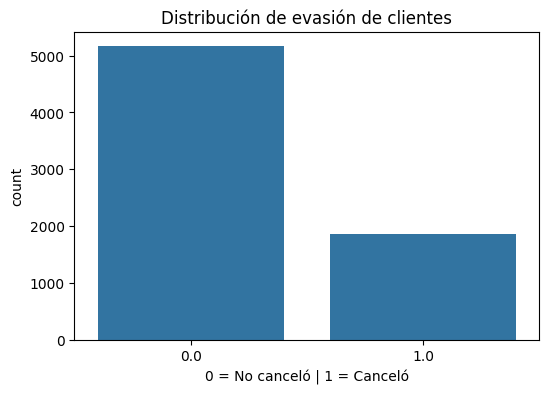

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Distribución de evasión de clientes")
plt.xlabel("0 = No canceló | 1 = Canceló")

plt.show()

##Insight esperado: normalmente la mayoría de clientes no cancela, pero existe una proporción importante de churn.

# **3. Evasión por variables categoricas:**


Ahora analizamos churn según caracteristicas del ciente.

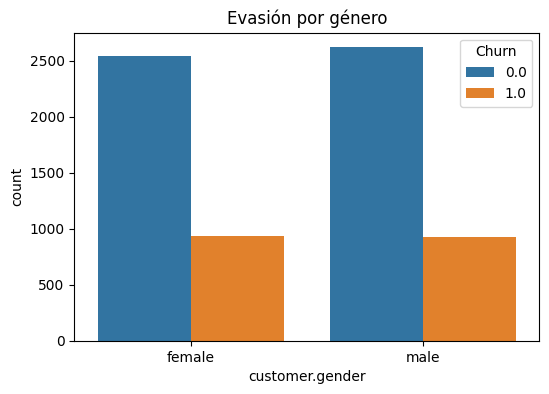

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="customer.gender", hue="Churn")

plt.title("Evasión por género")

plt.show()

# **4. Churn por tipo de contrato:**


Este gráfico suele mostrar uno de los insights más importantes.

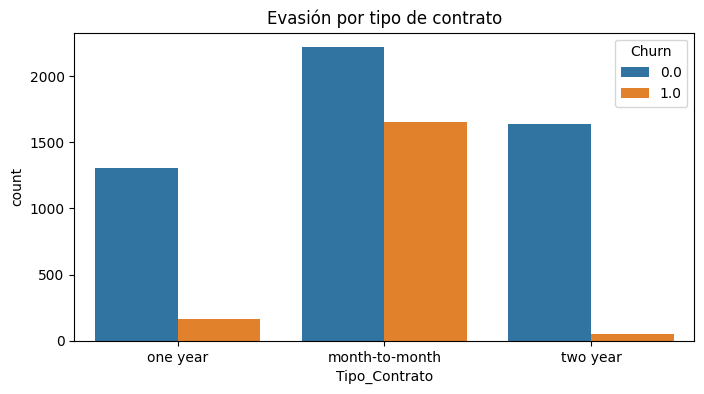

In [62]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x="Tipo_Contrato", hue="Churn")

plt.title("Evasión por tipo de contrato")

plt.show()

## Insight Comun:
## Los contratos mensuales tienen mayor Churn

# **5. Churn por metodo de pago:**



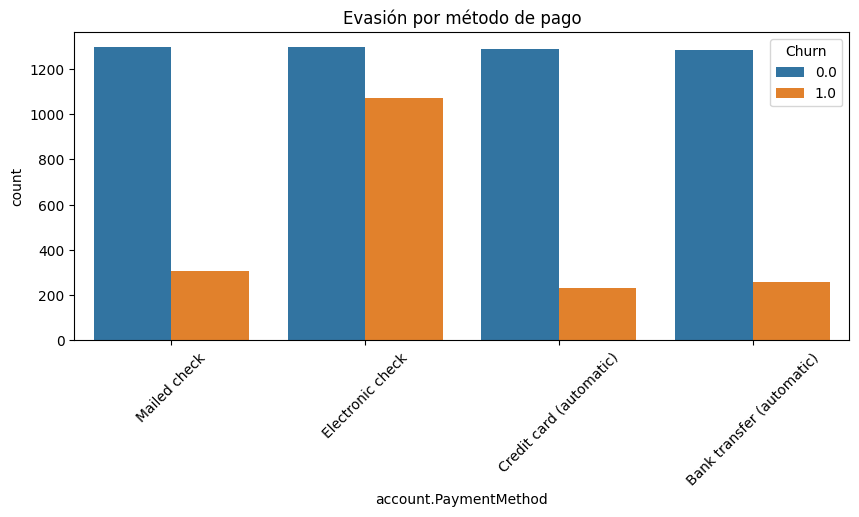

In [63]:
plt.figure(figsize=(10,4))

sns.countplot(data=df, x="account.PaymentMethod", hue="Churn")

plt.title("Evasión por método de pago")

plt.xticks(rotation=45)

plt.show()

# **6. Evasión por variables numéricas:**

Ahora analizamos como influyen los valores numéricos:


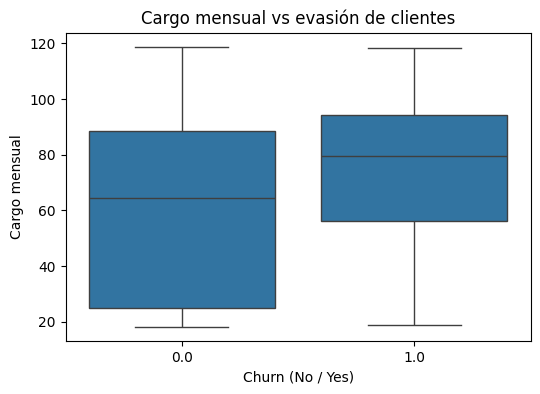

In [65]:
## Cargo mensual vs churn

plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Cargo_Mensual")

plt.title("Cargo mensual vs evasión de clientes")
plt.xlabel("Churn (No / Yes)")
plt.ylabel("Cargo mensual")

plt.show()


## Insight esperado:
##Normalmente los clientes con cargos mensuales más altos presentan mayor churn.

# **7. Tiempo de permanencia (Tenure) vs Churn:**

Esto permite ver si los clientes nuevos cancelan más.


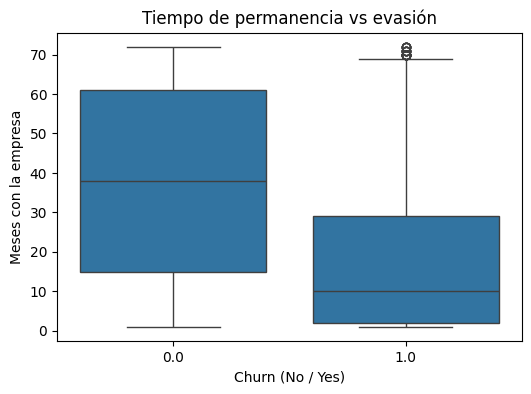

In [66]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Tenure")

plt.title("Tiempo de permanencia vs evasión")
plt.xlabel("Churn (No / Yes)")
plt.ylabel("Meses con la empresa")

plt.show()

# Insight esperado:

# Clientes con menor Tenure (poco tiempo en la empresa) tienen mayor probabilidad de cancelar.

# **8. Extra — Correlación entre variables**

Primero seleccionamos solo variables numéricas para visualizarlas.

*   Tenure
*   Cargo_Mensual
*   Cargo_Total
*   Cuentas_Diarias


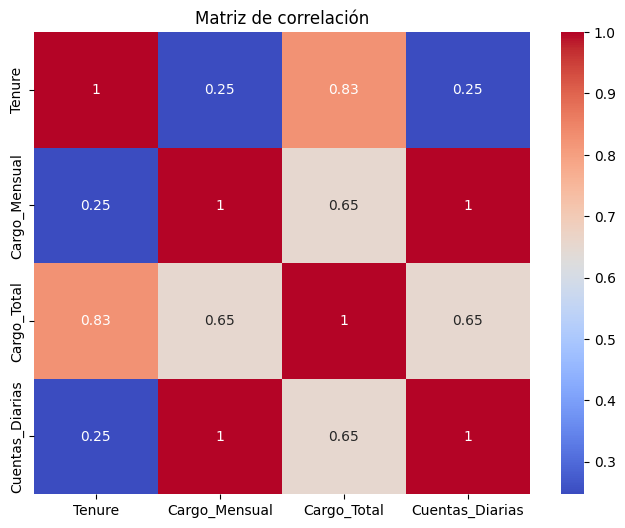

In [67]:
correlacion = df[["Tenure","Cargo_Mensual","Cargo_Total","Cuentas_Diarias"]].corr()

## Visualización

plt.figure(figsize=(8,6))

sns.heatmap(correlacion, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

Insight esperado:

Resultado:

Cargo_Total ↔ Tenure (correlación alta)

Cargo_Total ↔ Cargo_Mensual

Lo cual tiene sentido porque:

Cargo_Total ≈ Cargo_Mensual * Tenure

### **Tenure vs Cargo_Total**

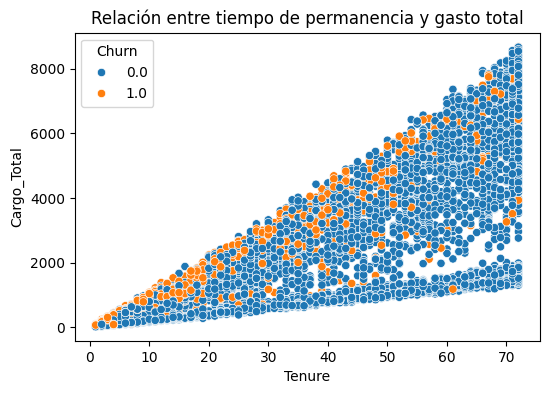

In [68]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=df, x="Tenure", y="Cargo_Total", hue="Churn")

plt.title("Relación entre tiempo de permanencia y gasto total")

plt.show()

# **📊 Informe Final - Análisis de Evasión de clientes (Churn)**

# **1️⃣ Introducción**

El presente análisis tiene como objetivo estudiar los factores asociados a la evasión de clientes (Churn) en la empresa Telecom X.
La evasión de clientes representa un problema importante para las empresas de telecomunicaciones, ya que implica pérdida de ingresos y mayores costos asociados a la adquisición de nuevos clientes.

En este proyecto se realizó un proceso de análisis de datos utilizando Python para identificar patrones en el comportamiento de los clientes y comprender qué variables pueden estar relacionadas con una mayor probabilidad de cancelación del servicio.

El análisis se desarrolló siguiendo un proceso de ETL (Extracción, Transformación y Carga) y posteriormente un Análisis Exploratorio de Datos (EDA) para identificar tendencias y generar insights que permitan apoyar la toma de decisiones estratégicas.


# **2️⃣ Limpieza y Tratamiento de Datos**

Durante esta etapa se realizaron diversas tareas para preparar los datos antes del análisis:

**Extracción de datos**

* Los datos fueron obtenidos desde una API en formato JSON.
* Se utilizó la biblioteca pandas para convertir los datos en un DataFrame.

**Transformación de datos**

* Se normalizó la estructura del JSON utilizando pd.json_normalize() para convertir los datos anidados en un formato tabular.
* Se revisaron los tipos de datos y se identificaron posibles inconsistencias.
* Se verificaron valores nulos y registros duplicados.

**Procesamiento y limpieza**

* Se corrigieron tipos de datos en variables numéricas.
* Se estandarizaron algunas columnas para facilitar el análisis.
* Se creó una nueva variable llamada Cuentas_Diarias, calculada a partir del cargo mensual dividido entre 30, para estimar el gasto diario de los clientes.

Estas transformaciones permitieron obtener un dataset limpio y estructurado listo para el análisis exploratorio.



# **3️⃣ Análisis Exploratorio de Datos (EDA)**


En esta etapa se analizaron diferentes variables para comprender cómo se distribuye la evasión de clientes.

_

**Distribución de evasión**

* Se analizó la distribución de la variable Churn, identificando la proporción de clientes que cancelaron el servicio frente a aquellos que permanecen activos.

* El análisis mostró que, aunque la mayoría de los clientes permanecen en la empresa, existe un porcentaje significativo de cancelaciones que merece ser analizado con mayor profundidad.

_

**Evasión por variables categóricas**

Se analizaron diversas variables categóricas para identificar patrones asociados al churn.

Entre los análisis realizados destacan:

* Churn por género
* Churn por tipo de contrato
* Churn por método de pago

Los resultados muestran que el tipo de contrato tiene una relación importante con la evasión, observándose mayores tasas de cancelación en contratos de corta duración.

_

**Evasión por variables numéricas**

También se analizaron variables numéricas para identificar posibles relaciones con el churn.

Se estudiaron variables como:

* Cargo mensual
* Tiempo de permanencia del cliente (Tenure)
* Gasto total

Los gráficos de distribución mostraron que:

* Los clientes con mayor cargo mensual presentan una mayor probabilidad de cancelación.
* Los clientes con menor tiempo de permanencia tienden a abandonar el servicio con mayor frecuencia.

Esto sugiere que los clientes nuevos son más propensos a cancelar su suscripción.

# 4️⃣ **Conclusiones y recomendaciones:**

A partir del análisis exploratorio se identificaron varios patrones relevantes en el comportamiento de los clientes.

--

**Principales hallazgos**

* Los clientes con contratos mensuales presentan mayores tasas de churn en comparación con contratos a largo plazo.

* Los clientes con menor tiempo de permanencia en la empresa tienen mayor probabilidad de cancelar el servicio.

* Los cargos mensuales más elevados están asociados con una mayor tasa de cancelación.

* Los clientes nuevos parecen ser más sensibles a factores como el precio o la calidad del servicio.

Estos hallazgos sugieren que la retención de clientes en los primeros meses de relación con la empresa es un factor clave para reducir la evasión.


--

# **5️⃣ Recomendaciones**

Con base en los resultados obtenidos, se proponen las siguientes acciones estratégicas:

1️⃣ **Incentivar contratos de largo plazo**

Ofrecer beneficios o descuentos a los clientes que opten por contratos anuales puede ayudar a reducir la tasa de churn.

2️⃣ **Programas de fidelización para nuevos clientes**

Implementar estrategias de onboarding y fidelización durante los primeros meses de servicio puede ayudar a mejorar la retención.

3️⃣ **Revisión de planes con cargos elevados**

Analizar los planes con mayor costo mensual para evaluar si el valor percibido por el cliente justifica el precio.

4️⃣ **Análisis predictivo**

Utilizar modelos de machine learning para predecir la probabilidad de churn y tomar acciones preventivas antes de que el cliente cancele.

--


# **⭐ Análisis extra: correlación entre variables**

Se realizó un análisis de correlación entre variables numéricas para identificar posibles relaciones entre ellas.

El análisis mostró correlaciones esperadas entre variables como:

* Cargo mensual
* Cargo total
* Tiempo de permanencia

Estas relaciones indican que el gasto total de un cliente está directamente influenciado por el tiempo que ha permanecido en la empresa y el costo mensual del servicio.

Este tipo de análisis puede ser útil para el desarrollo de modelos predictivos de churn en futuras etapas del proyecto.

--

# **🚀 Resultado final del proyecto**

Este análisis permitió identificar factores clave asociados a la evasión de clientes en Telecom X, proporcionando información valiosa para diseñar estrategias de retención y mejorar la experiencia del cliente.

Los insights obtenidos pueden servir como base para el desarrollo de modelos predictivos de churn, que permitan anticipar la cancelación de clientes y aplicar acciones preventivas.